In [165]:
import backtrader as bt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [47]:
# Select 20 varied tickers
tickers = [
    "SPY",
    "AAPL",
    "MSFT",
    "XOM",
    "JPM",
    "PG",
    "NEE",
    "AMZN",
    "TSLA",
    "AMT",
    "BKR",
    "DUK",
    "ED",
    "JNJ",
    "PFE",
    "GS",
    "META",
    "BA",
    "CAT",
    "CVX",
    "GD",
    "NFLX",
]
# tickers = ['NEE', 'PG', 'JNJ', 'JPM', 'XOM', 'CVX', 'AAPL', 'NVDA', 'AMZN']
# Pull 2 years of daily candle data (OHLCV)
data = yf.download(tickers, start="2024-01-01", end="2026-01-01")["Close"]

[*********************100%***********************]  22 of 22 completed


In [86]:
returns = data.pct_change().dropna()

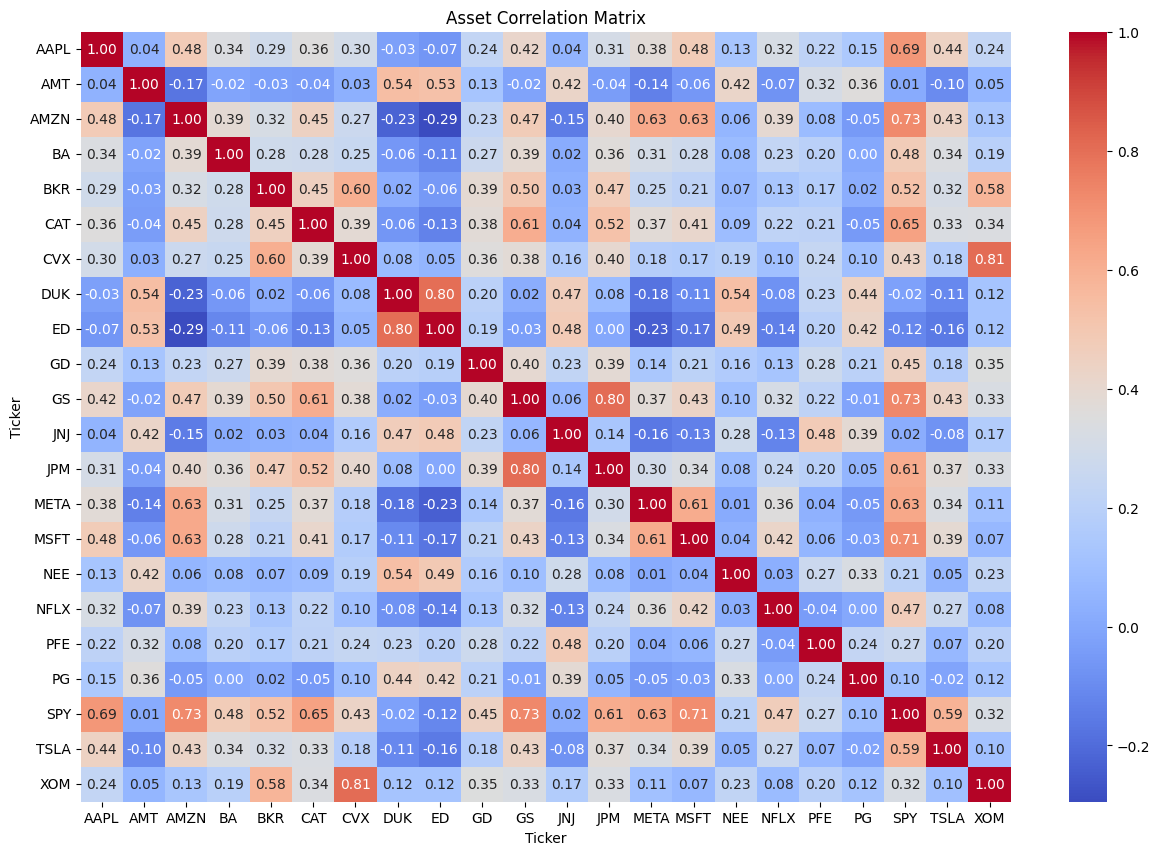

In [49]:
# Generate the correlation matrix
corr_matrix = returns.corr()

# Plotting the Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Asset Correlation Matrix")
plt.show()

In [51]:
benchmark = returns["SPY"]
util_tech_port = returns.loc[:, ["DUK", "ED", "META", "MSFT"]]
tech_only_port = returns.loc[:, ["AAPL", "TSLA", "AMZN", "NFLX"]]

In [76]:
momentum_lookback = 252
reversal_skip = 21

util_tech_mom = (util_tech_port.shift(reversal_skip) / util_tech_port.shift(momentum_lookback)) - 1
util_tech_mom = util_tech_mom.dropna()
tech_only_mom = (tech_only_port.shift(reversal_skip) / util_tech_port.shift(momentum_lookback)) - 1
tech_only_mom = tech_only_mom.dropna()

In [77]:
def calculate_rsi(df, window=14):
    delta = df.diff()
    # Separate gains and losses
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()

    # Calculate RS and RSI
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

In [78]:
util_tech_rsi = calculate_rsi(util_tech_port).dropna()
tech_only_ris = calculate_rsi(tech_only_port).dropna()

In [79]:
# axis=1 ranks across the stocks for each specific day
# pct=True scales the rank between 0 and 1
util_tech_rsi_rank = util_tech_rsi.rank(axis=1, pct=True)

# For Momentum, we want the highest values (Top = 1.0)
util_tech_mom_rank = util_tech_mom.rank(axis=1, pct=True)

# For RSI, we usually want the lowest values (Oversold = 0.0)
# But often we flip it so 1.0 is the "strongest buy signal"
util_tech_rsi_rank_buy_signal = 1 - util_tech_rsi_rank

In [84]:
# Get the top 2 momentum stocks for a specific day
top_mom = util_tech_mom_rank.loc["2025-01-03"].nlargest(2)
print("Top Momentum Bets:\n", top_mom)

# Get the most oversold RSI stocks
top_oversold = util_tech_rsi_rank.loc["2025-01-03"].nsmallest(2)
print("\nTop Mean Reversion Bets:\n", top_oversold)

Top Momentum Bets:
 Ticker
MSFT    1.00
DUK     0.75
Name: 2025-01-03 00:00:00, dtype: float64

Top Mean Reversion Bets:
 Ticker
DUK    0.25
ED     0.50
Name: 2025-01-03 00:00:00, dtype: float64


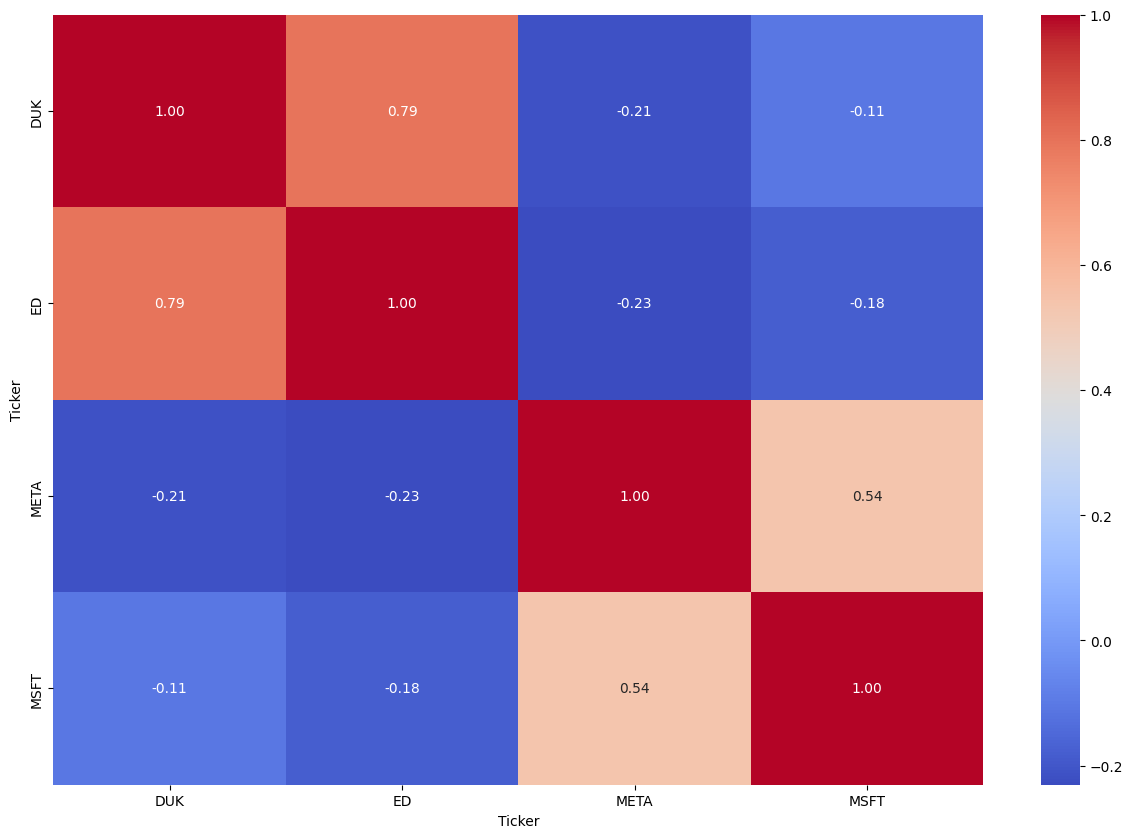

In [72]:
techutil_rsi_corr = util_tech_rsi.corr()

# Plotting the Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(techutil_rsi_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

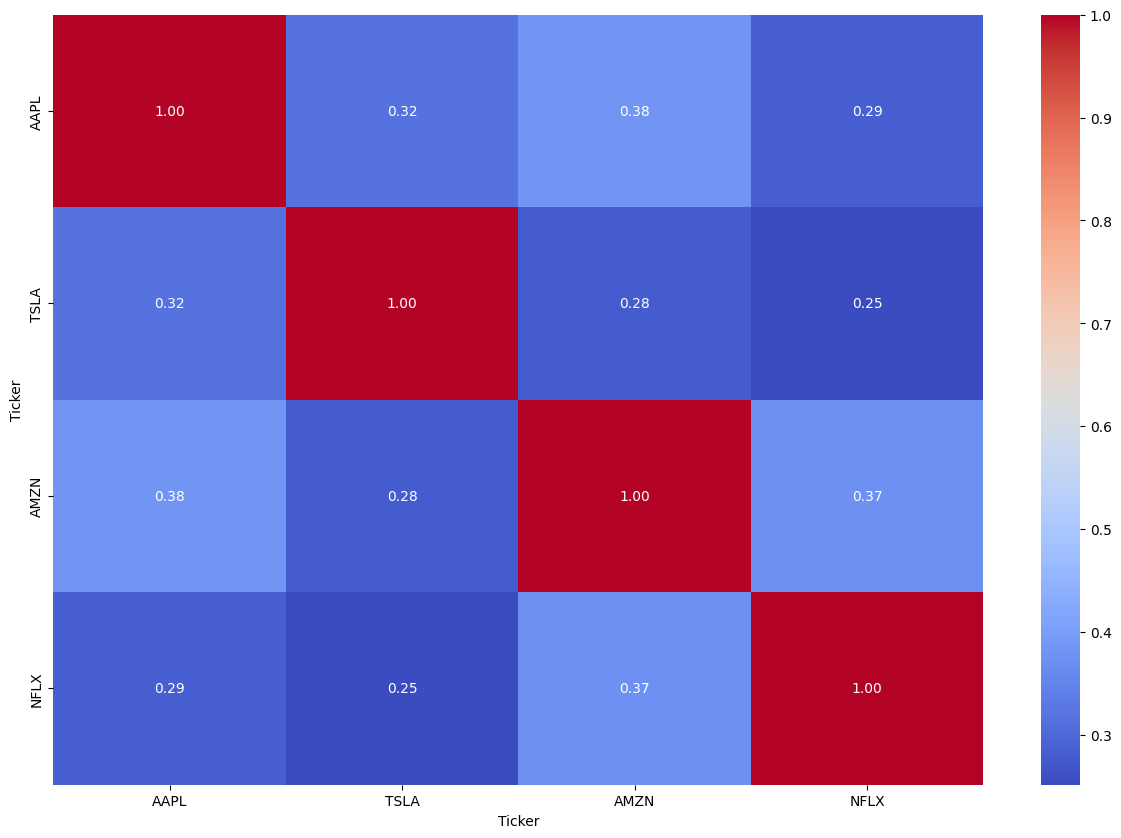

In [71]:
tech_rsi_corr = tech_only_ris.corr()

# Plotting the Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(tech_rsi_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

<Axes: xlabel='Date'>

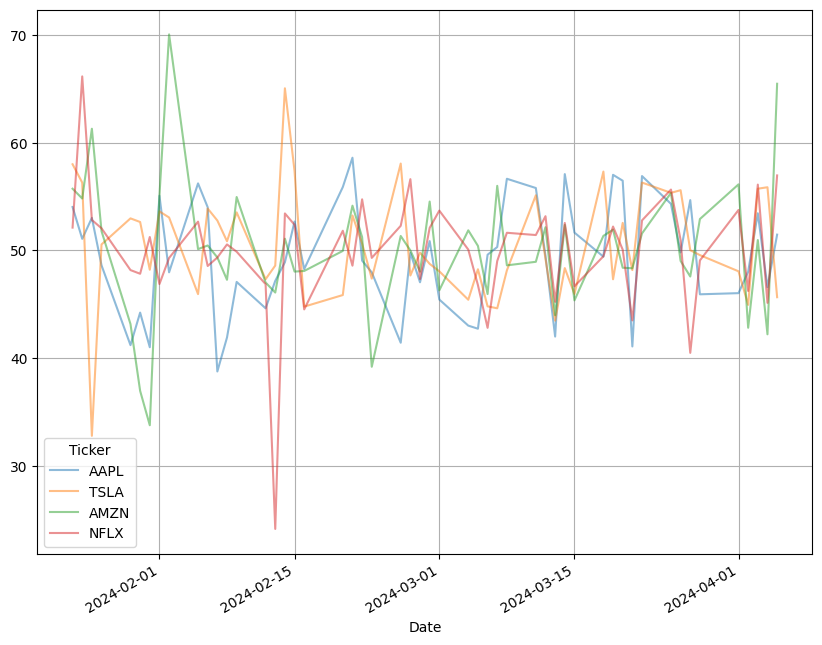

In [70]:
tech_only_ris.loc["2024-01-23":"2024-04-05"].plot(grid=True, figsize=(10, 8), alpha=0.5)

<Axes: xlabel='Date'>

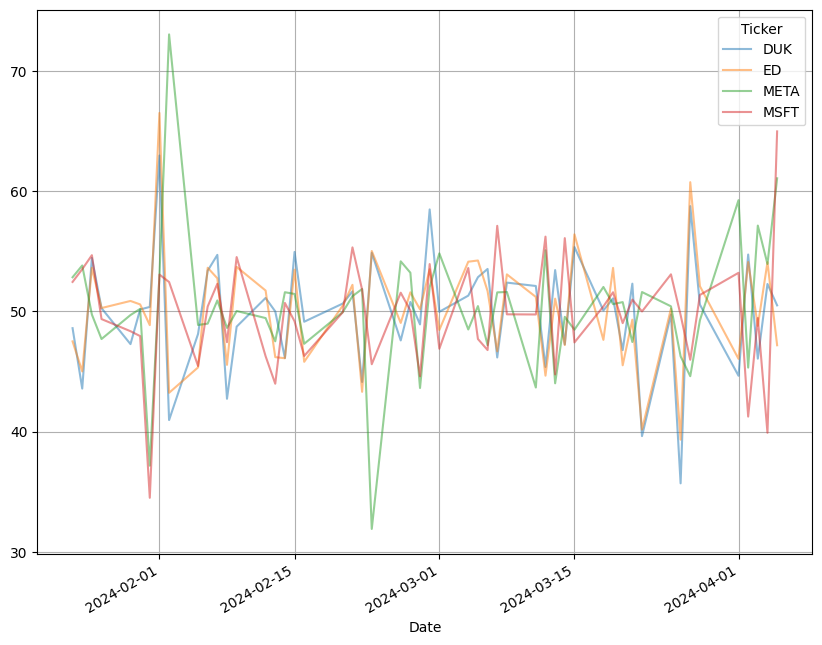

In [69]:
util_tech_rsi.loc["2024-01-23":"2024-04-05"].plot(grid=True, figsize=(10, 8), alpha=0.5)

## BB Strategy

In [94]:
spy_df = yf.download("TSLA", start="2024-01-01", end="2025-12-31")
spy_df = spy_df["Close"]

[*********************100%***********************]  1 of 1 completed


In [179]:
tsla_df = yf.download("TSLA", start="2024-01-01", end="2025-12-31")

tsla_ft = pd.DataFrame()
tsla_ft["close"] = tsla_df.loc[:, ("Close", "TSLA")]
tsla_ft["sma_20"] = tsla_ft["close"].rolling(window=20).mean()
tsla_ft["std_20"] = tsla_ft["close"].rolling(window=20).std()
tsla_ft["upper"] = tsla_ft["sma_20"] + (tsla_ft["std_20"] * 3.0)
tsla_ft["lower"] = tsla_ft["sma_20"] - (tsla_ft["std_20"] * 1.0)
tsla_ft = tsla_ft.dropna()

tsla_ft["signal"] = 0
tsla_ft.loc[tsla_ft["close"] < tsla_ft["lower"], "signal"] = 1  # NOTE: buy
tsla_ft.loc[tsla_ft["close"] > tsla_ft["upper"], "signal"] = -1  # NOTE: sell

[*********************100%***********************]  1 of 1 completed


In [180]:
tsla_ft["signal"].value_counts()

signal
 0    384
 1     96
-1      2
Name: count, dtype: int64

In [181]:
tsla_ft["asset_ret"] = tsla_ft["close"].pct_change()
tsla_ft["strat_ret"] = tsla_ft["signal"].shift(1) * tsla_ft["asset_ret"]
tsla_ft["cum_asset_ret"] = (1 + tsla_ft["asset_ret"]).cumprod()
tsla_ft["cum_strat_ret"] = (1 + tsla_ft["strat_ret"]).cumprod()

In [182]:
print("strat SR: ", tsla_ft["strat_ret"].mean() / tsla_ft["strat_ret"].std() * np.sqrt(252))
print("asset SR: ", tsla_ft["asset_ret"].mean() / tsla_ft["asset_ret"].std() * np.sqrt(252))

strat SR:  0.8301801190083763
asset SR:  1.022890124821004


<Axes: xlabel='Date'>

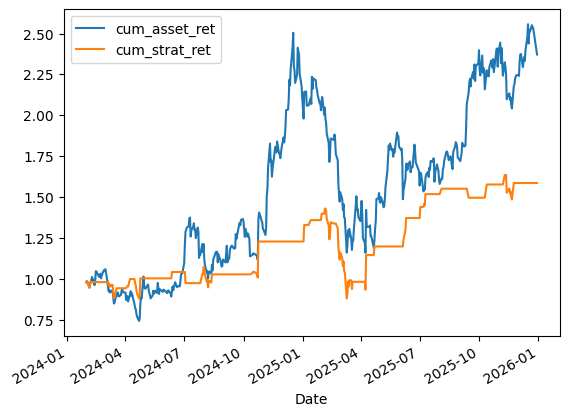

In [183]:
tsla_ft[["cum_asset_ret", "cum_strat_ret"]].plot()